# Dijkstra's Algorithm — Interactive Step-by-Step Notebook

This notebook walks through Dijkstra's shortest-path algorithm **one step at a time**.

**What you will do:**
1. Build the graph
2. Understand how node positions work (and why they are separate from the algorithm)
3. Step through the algorithm interactively in a full-screen visualizer
4. View all steps at once as a static grid
5. Reconstruct and display the final shortest path
6. Solve practice exercises


## 1. Setup

In [13]:
import heapq, math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
print("Libraries loaded.")


Libraries loaded.


## 2. The Graph

We represent connections as an **adjacency list**.  
Each node maps to a list of `(neighbor, weight)` pairs.

```
        4         5
   A ———————B —————— D
   |      / |      / |
  2|    1/  |1   1/  |3
   |   /    |   /    |
   C ————————E —————— F
         5        4
```


In [14]:
graph = {
    'A': [('B', 4), ('C', 2)],
    'B': [('A', 4), ('C', 1), ('D', 5), ('E', 1)],
    'C': [('A', 2), ('B', 1), ('E', 5)],
    'D': [('B', 5), ('E', 1), ('F', 3)],
    'E': [('B', 1), ('C', 5), ('D', 1), ('F', 4)],
    'F': [('D', 3), ('E', 4)],
}
nodes = list(graph.keys())
print("Nodes:", nodes)
print("Neighbors of B:", graph['B'])


Nodes: ['A', 'B', 'C', 'D', 'E', 'F']
Neighbors of B: [('A', 4), ('C', 1), ('D', 5), ('E', 1)]


## 3. Node Positions — What Are They?

> **"What is `positions`? Why do I need it?"**

`positions` is a dictionary that tells **matplotlib where to draw each circle on the canvas**.
It has **nothing to do** with the algorithm — Dijkstra only cares about edge weights.

Think of it like a map:
- The algorithm finds the *shortest route* between cities
- The positions are the *latitude/longitude* of each city on the printed map

```
Canvas coordinate system:

  y=2  .  B  .  .  D  .
  y=1  A  .  .  .  .  F
  y=0  .  C  .  .  E  .
       x=0  1.5  3   4.5
```

You can move nodes anywhere — the algorithm output stays identical.


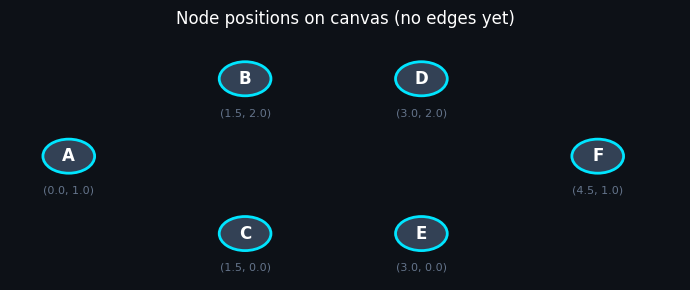

↑ Positions only — no algorithm involved here.


In [15]:
# These are purely for drawing — (x, y) on the matplotlib canvas
positions = {
    'A': (0.0, 1.0),   # left-middle
    'B': (1.5, 2.0),   # top-centre-left
    'C': (1.5, 0.0),   # bottom-centre-left
    'D': (3.0, 2.0),   # top-centre-right
    'E': (3.0, 0.0),   # bottom-centre-right
    'F': (4.5, 1.0),   # right-middle
}

# Quick sanity-check: draw just the positions
fig, ax = plt.subplots(figsize=(7, 3))
ax.set_facecolor('#0d1117'); fig.patch.set_facecolor('#0d1117')
ax.set_title("Node positions on canvas (no edges yet)", color='white')
ax.set_xlim(-0.5, 5.2); ax.set_ylim(-0.6, 2.6); ax.axis('off')
for node, (x, y) in positions.items():
    ax.add_patch(plt.Circle((x, y), 0.22, color='#334155', ec='#00e5ff', lw=2))
    ax.text(x, y,   node, ha='center', va='center', color='white', fontweight='bold', fontsize=12)
    ax.text(x, y-0.38, f"({x}, {y})", ha='center', va='top', color='#64748b', fontsize=8)
plt.tight_layout(); plt.show()
print("↑ Positions only — no algorithm involved here.")


## 4. Dijkstra — Record Every Step

Instead of running the algorithm all at once, we **record a snapshot after each action**.
Each snapshot stores:
- `dist` — current best distances
- `visited` — which nodes are finalized
- `current` — the node being processed right now
- `updated` — neighbors just relaxed
- `message` — a human-readable explanation


In [16]:
def dijkstra_steps(graph, source):
    dist    = {n: math.inf for n in graph}
    prev    = {n: None     for n in graph}
    visited = {n: False    for n in graph}
    dist[source] = 0

    pq    = [(0, source)]
    steps = []

    def snap(current=None, updated=None, message=""):
        steps.append({
            'dist':    dist.copy(),
            'prev':    prev.copy(),
            'visited': visited.copy(),
            'current': current,
            'updated': updated or [],
            'message': message,
        })

    snap(message=f"Start: set dist[{source}]=0, all others=inf. Push {source} onto the queue.")

    while pq:
        d_u, u = heapq.heappop(pq)

        if visited[u]:
            snap(current=u, message=f"'{u}' already visited — skip it.")
            continue

        visited[u] = True
        snap(current=u, message=f"Dequeue '{u}' (dist={d_u}). Mark as VISITED.")

        updated = []
        for v, w in graph[u]:
            if visited[v]:
                continue
            nd = dist[u] + w
            if nd < dist[v]:
                dist[v] = nd
                prev[v] = u
                heapq.heappush(pq, (nd, v))
                updated.append(v)

        msg = (f"Relax edges from '{u}': improved "
               + ", ".join(f"{v}->{dist[v]}" for v in updated)
               if updated else f"No improvements from '{u}'.")
        snap(current=u, updated=updated, message=msg)

    path, cur = [], 'F'
    while cur: path.append(cur); cur = prev[cur]
    path.reverse()
    snap(message=f"Done! Shortest path A->F: {' -> '.join(path)}  (cost={dist['F']})",
         updated=path)

    return steps, dist, prev

steps, dist, prev = dijkstra_steps(graph, source='A')
print(f"Recorded {len(steps)} steps.")
for i, s in enumerate(steps):
    print(f"  Step {i:02d}: {s['message']}")


Recorded 17 steps.
  Step 00: Start: set dist[A]=0, all others=inf. Push A onto the queue.
  Step 01: Dequeue 'A' (dist=0). Mark as VISITED.
  Step 02: Relax edges from 'A': improved B->4, C->2
  Step 03: Dequeue 'C' (dist=2). Mark as VISITED.
  Step 04: Relax edges from 'C': improved B->3, E->7
  Step 05: Dequeue 'B' (dist=3). Mark as VISITED.
  Step 06: Relax edges from 'B': improved D->8, E->4
  Step 07: 'B' already visited — skip it.
  Step 08: Dequeue 'E' (dist=4). Mark as VISITED.
  Step 09: Relax edges from 'E': improved D->5, F->8
  Step 10: Dequeue 'D' (dist=5). Mark as VISITED.
  Step 11: No improvements from 'D'.
  Step 12: 'E' already visited — skip it.
  Step 13: 'D' already visited — skip it.
  Step 14: Dequeue 'F' (dist=8). Mark as VISITED.
  Step 15: No improvements from 'F'.
  Step 16: Done! Shortest path A->F: A -> C -> B -> E -> F  (cost=8)


## 5. Frame Drawing Function

This function renders a single algorithm snapshot onto a matplotlib axes.
It is used by the static grid view (Section 7) and the exercise solutions below.

Color legend:

| Node color     | Meaning                    |
|----------------|----------------------------|
| Cyan border    | Currently being processed  |
| Purple         | Visited (distance final)   |
| Orange border  | Just relaxed this step     |
| Dark           | Unvisited                  |
| Gold           | Final shortest path        |


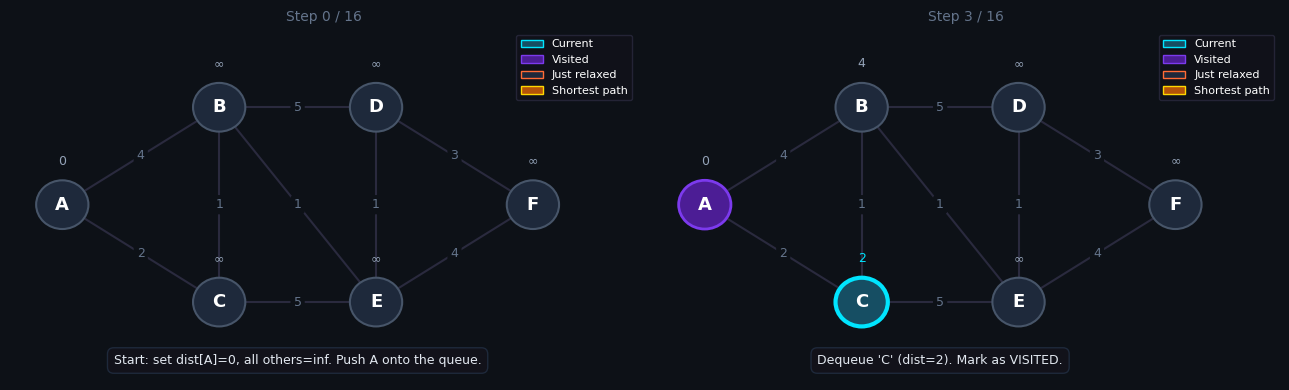

In [17]:
def draw_frame(ax, snap, positions, graph, step_num, total):
    ax.clear()
    ax.set_facecolor('#0d1117')
    ax.set_xlim(-0.5, 5.5); ax.set_ylim(-0.8, 2.8); ax.axis('off')

    dist    = snap['dist']
    visited = snap['visited']
    current = snap['current']
    updated = snap['updated']
    is_done = (step_num == total - 1)

    # ── Draw edges ────────────────────────────────────────────────
    drawn = set()
    for u, nbrs in graph.items():
        for v, w in nbrs:
            if (v, u) in drawn: continue
            drawn.add((u, v))
            x1,y1 = positions[u]; x2,y2 = positions[v]
            on_path = is_done and u in updated and v in updated
            color = '#ffd700' if on_path else '#2a2a3e'
            lw    = 3.0       if on_path else 1.5
            ax.plot([x1,x2],[y1,y2], color=color, lw=lw, zorder=1, solid_capstyle='round')
            mx,my = (x1+x2)/2,(y1+y2)/2
            ax.text(mx, my, str(w), color='#64748b', fontsize=9, ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.25', fc='#0d1117', ec='none'), zorder=2)

    # ── Draw nodes ────────────────────────────────────────────────
    for node, (x, y) in positions.items():
        # Fill color
        if is_done and node in updated:
            fc = '#b45309'; ec = '#ffd700'; ew = 3
        elif node == current:
            fc = '#164e63'; ec = '#00e5ff'; ew = 3
        elif visited[node]:
            fc = '#4c1d95'; ec = '#7c3aed'; ew = 2
        elif node in updated:
            fc = '#1e293b'; ec = '#ff6b35'; ew = 3
        else:
            fc = '#1e293b'; ec = '#475569'; ew = 1.5

        ax.add_patch(plt.Circle((x,y), 0.25, color=fc, ec=ec, lw=ew, zorder=3))
        tc = '#000' if (is_done and node in updated) else '#fff'
        ax.text(x, y, node, ha='center', va='center', fontsize=13,
                fontweight='bold', color=tc, zorder=4)

        # Distance label above node
        d = dist[node]
        d_str = str(d) if d != math.inf else '∞'
        dc = '#00e5ff' if node==current else ('#ffd700' if is_done and node in updated else '#94a3b8')
        ax.text(x, y+0.38, d_str, ha='center', va='bottom', fontsize=9, color=dc, zorder=4)

    # ── Step message ──────────────────────────────────────────────
    ax.text(2.25, -0.6, snap['message'], ha='center', va='center',
            fontsize=9, color='#e2e8f0', wrap=True,
            bbox=dict(boxstyle='round,pad=0.5', fc='#12121a', ec='#1e293b'))
    ax.set_title(f"Step {step_num} / {total-1}", color='#64748b', fontsize=10)

    # ── Legend ────────────────────────────────────────────────────
    legend_items = [
        mpatches.Patch(color='#164e63', ec='#00e5ff', label='Current'),
        mpatches.Patch(color='#4c1d95', ec='#7c3aed', label='Visited'),
        mpatches.Patch(color='#1e293b', ec='#ff6b35', label='Just relaxed'),
        mpatches.Patch(color='#b45309', ec='#ffd700', label='Shortest path'),
    ]
    ax.legend(handles=legend_items, loc='upper right', fontsize=8,
              facecolor='#12121a', edgecolor='#2a2a3e', labelcolor='white')

# Preview step 0 and step 3
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor('#0d1117')
draw_frame(axes[0], steps[0], positions, graph, 0, len(steps))
draw_frame(axes[1], steps[3], positions, graph, 3, len(steps))
plt.tight_layout()
plt.show()


## 6. Step-by-Step Interactive Walkthrough

Run the cell below to open a full-screen interactive window.

- Use **Next >>** and **<< Prev** buttons to move through the algorithm one step at a time
- The message at the top of the window explains what is happening at each stage
- Keyboard shortcuts: arrow keys, Space (next), Esc (close)


In [24]:
import subprocess, sys, os

script = os.path.join(os.path.dirname(os.path.abspath('dijkstra_pygame.py')), 'dijkstra_pygame.py')
subprocess.Popen([sys.executable, script])
print("Pygame window launched.")
print("Controls: [Next >>] / [<< Prev] buttons   |   Arrow keys   |   Space = next   |   Esc = close")


Pygame window launched.
Controls: [Next >>] / [<< Prev] buttons   |   Arrow keys   |   Space = next   |   Esc = close


## 7. All Steps at a Glance

This cell renders every algorithm step as a static grid.
Useful for reviewing all steps at once, printing, or studying offline.


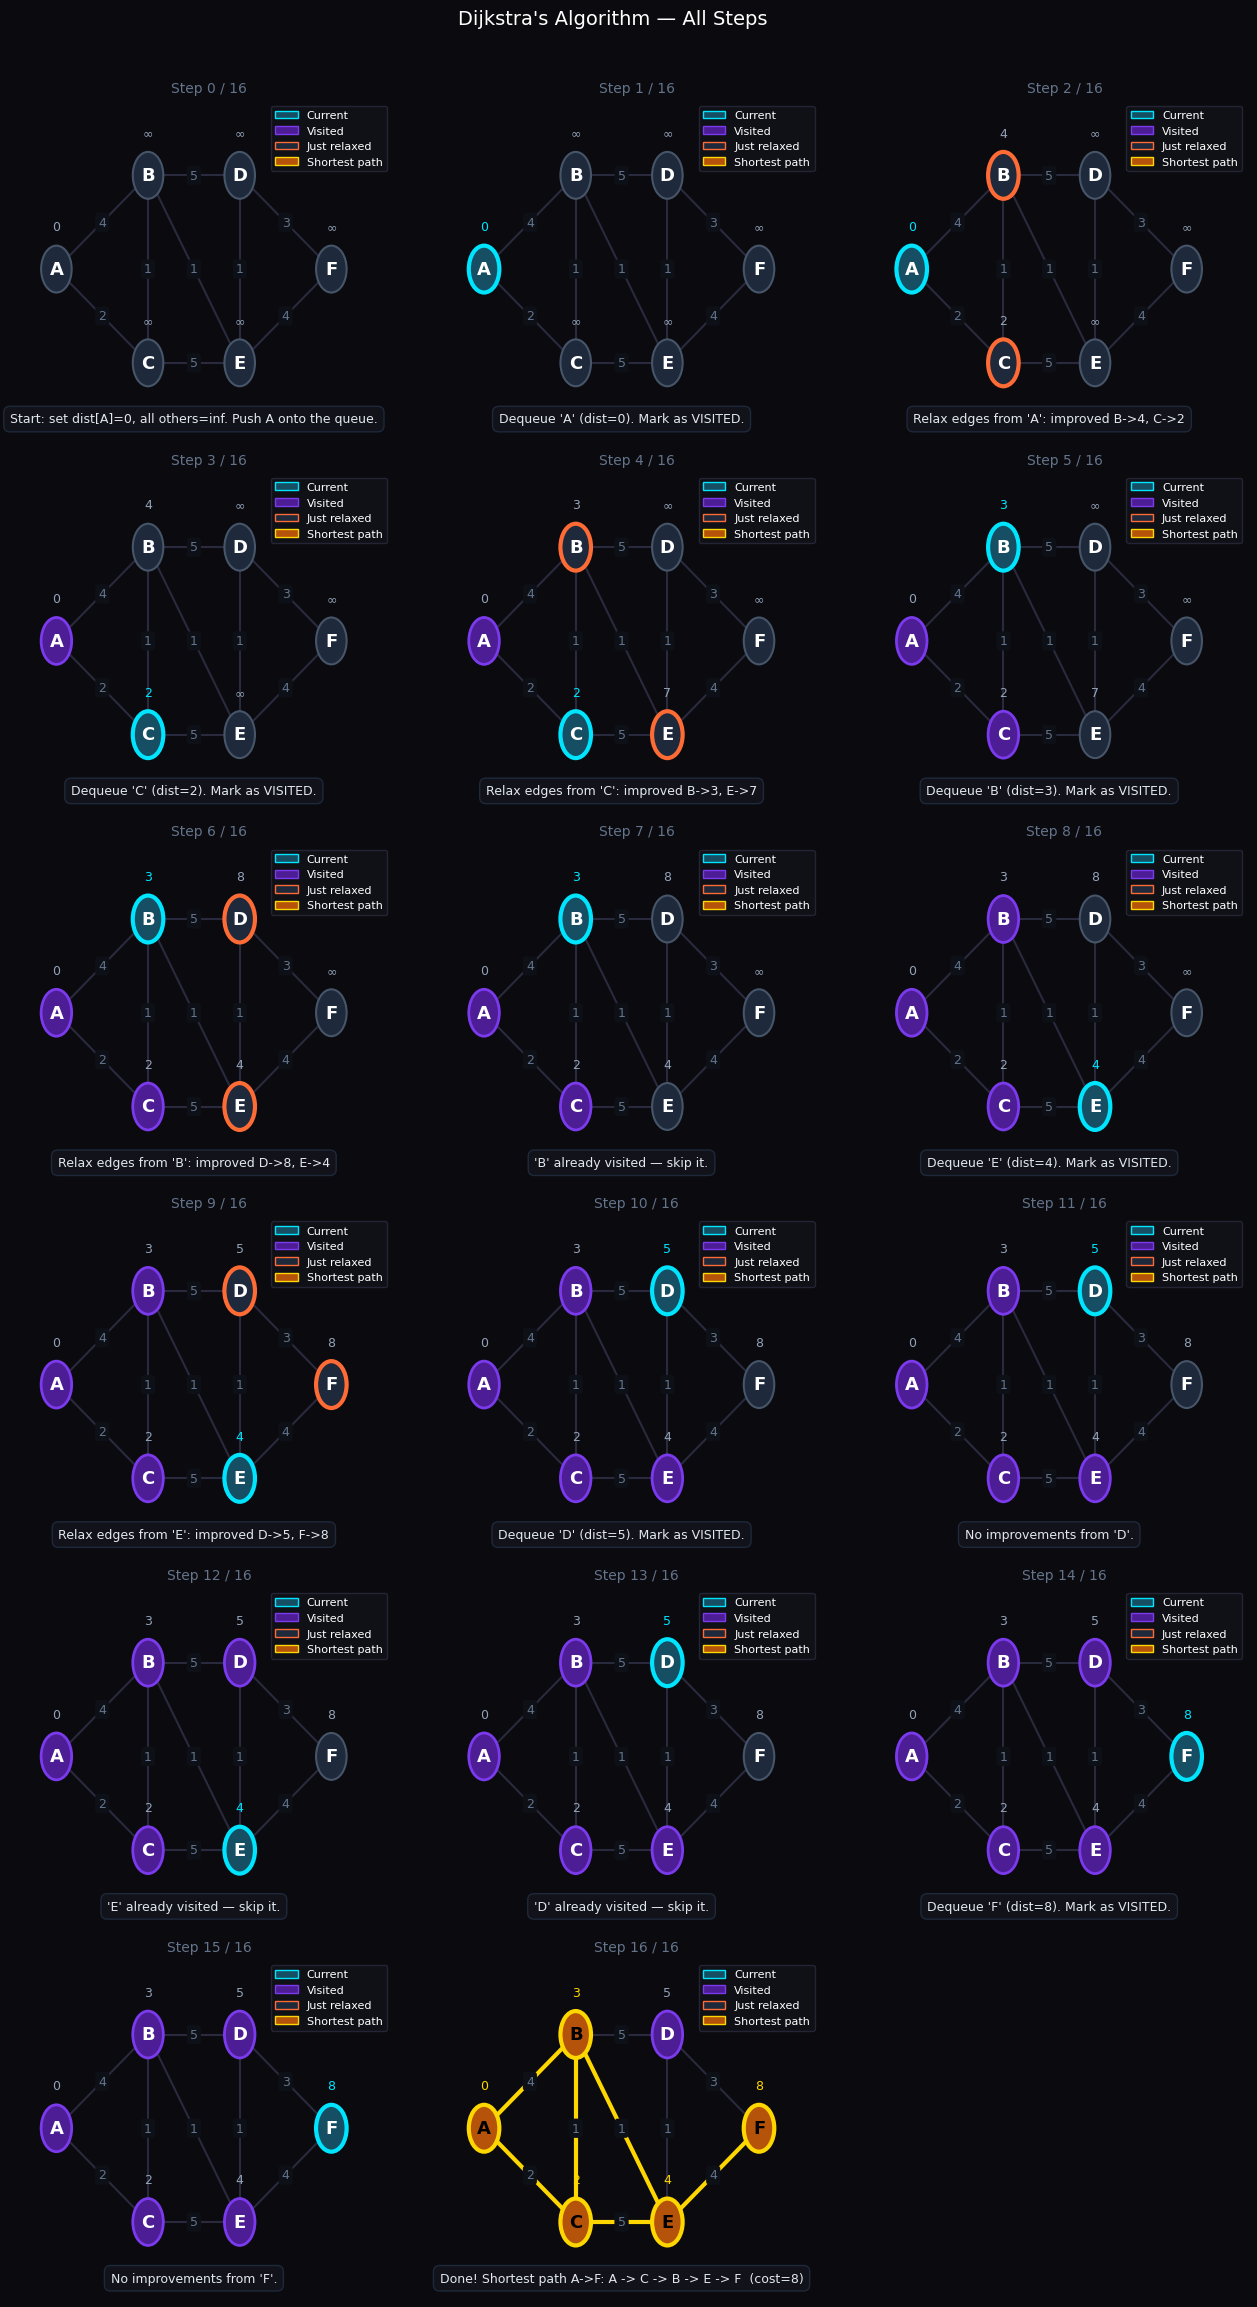

In [19]:
n = len(steps)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(13, rows * 3.8))
fig.patch.set_facecolor('#0a0a0f')
axes = axes.flatten()

for i, snap in enumerate(steps):
    draw_frame(axes[i], snap, positions, graph, i, n)

# Hide unused axes
for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Dijkstra's Algorithm — All Steps", color='white', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 8. Final Distance Table & Path Reconstruction


In [20]:
def reconstruct_path(prev, source, target):
    path, cur = [], target
    while cur:
        path.append(cur); cur = prev[cur]
    path.reverse()
    return path if path and path[0] == source else []

print(f"{'Node':>6} | {'Shortest Dist':>14} | {'Via':>4} | Path from A")
print("-" * 55)
for node in sorted(dist):
    path = reconstruct_path(prev, 'A', node)
    d    = dist[node]
    via  = prev[node] or '—'
    print(f"{node:>6} | {str(d):>14} | {via:>4} | {' → '.join(path)}")


  Node |  Shortest Dist |  Via | Path from A
-------------------------------------------------------
     A |              0 |    — | A
     B |              3 |    C | A → C → B
     C |              2 |    A | A → C
     D |              5 |    E | A → C → B → E → D
     E |              4 |    B | A → C → B → E
     F |              8 |    E | A → C → B → E → F


## 9. Complexity

| Implementation | Time | Space |
|---|---|---|
| Naive (scan for min) | O(V²) | O(V) |
| **Binary heap (heapq)** — used in this notebook | **O((V+E) log V)** | O(V+E) |
| Fibonacci heap | O(E + V log V) | O(V+E) |

**V** = vertices, **E** = edges.

Note: Dijkstra requires **non-negative** edge weights. Use Bellman-Ford for graphs with negative weights.


## 10. Practice Exercises

### A — Different source
Run the algorithm from node `'D'`. Display all steps as a grid and find the shortest path to `'A'`.


D -> A: cost=5, path=D -> E -> B -> C -> A


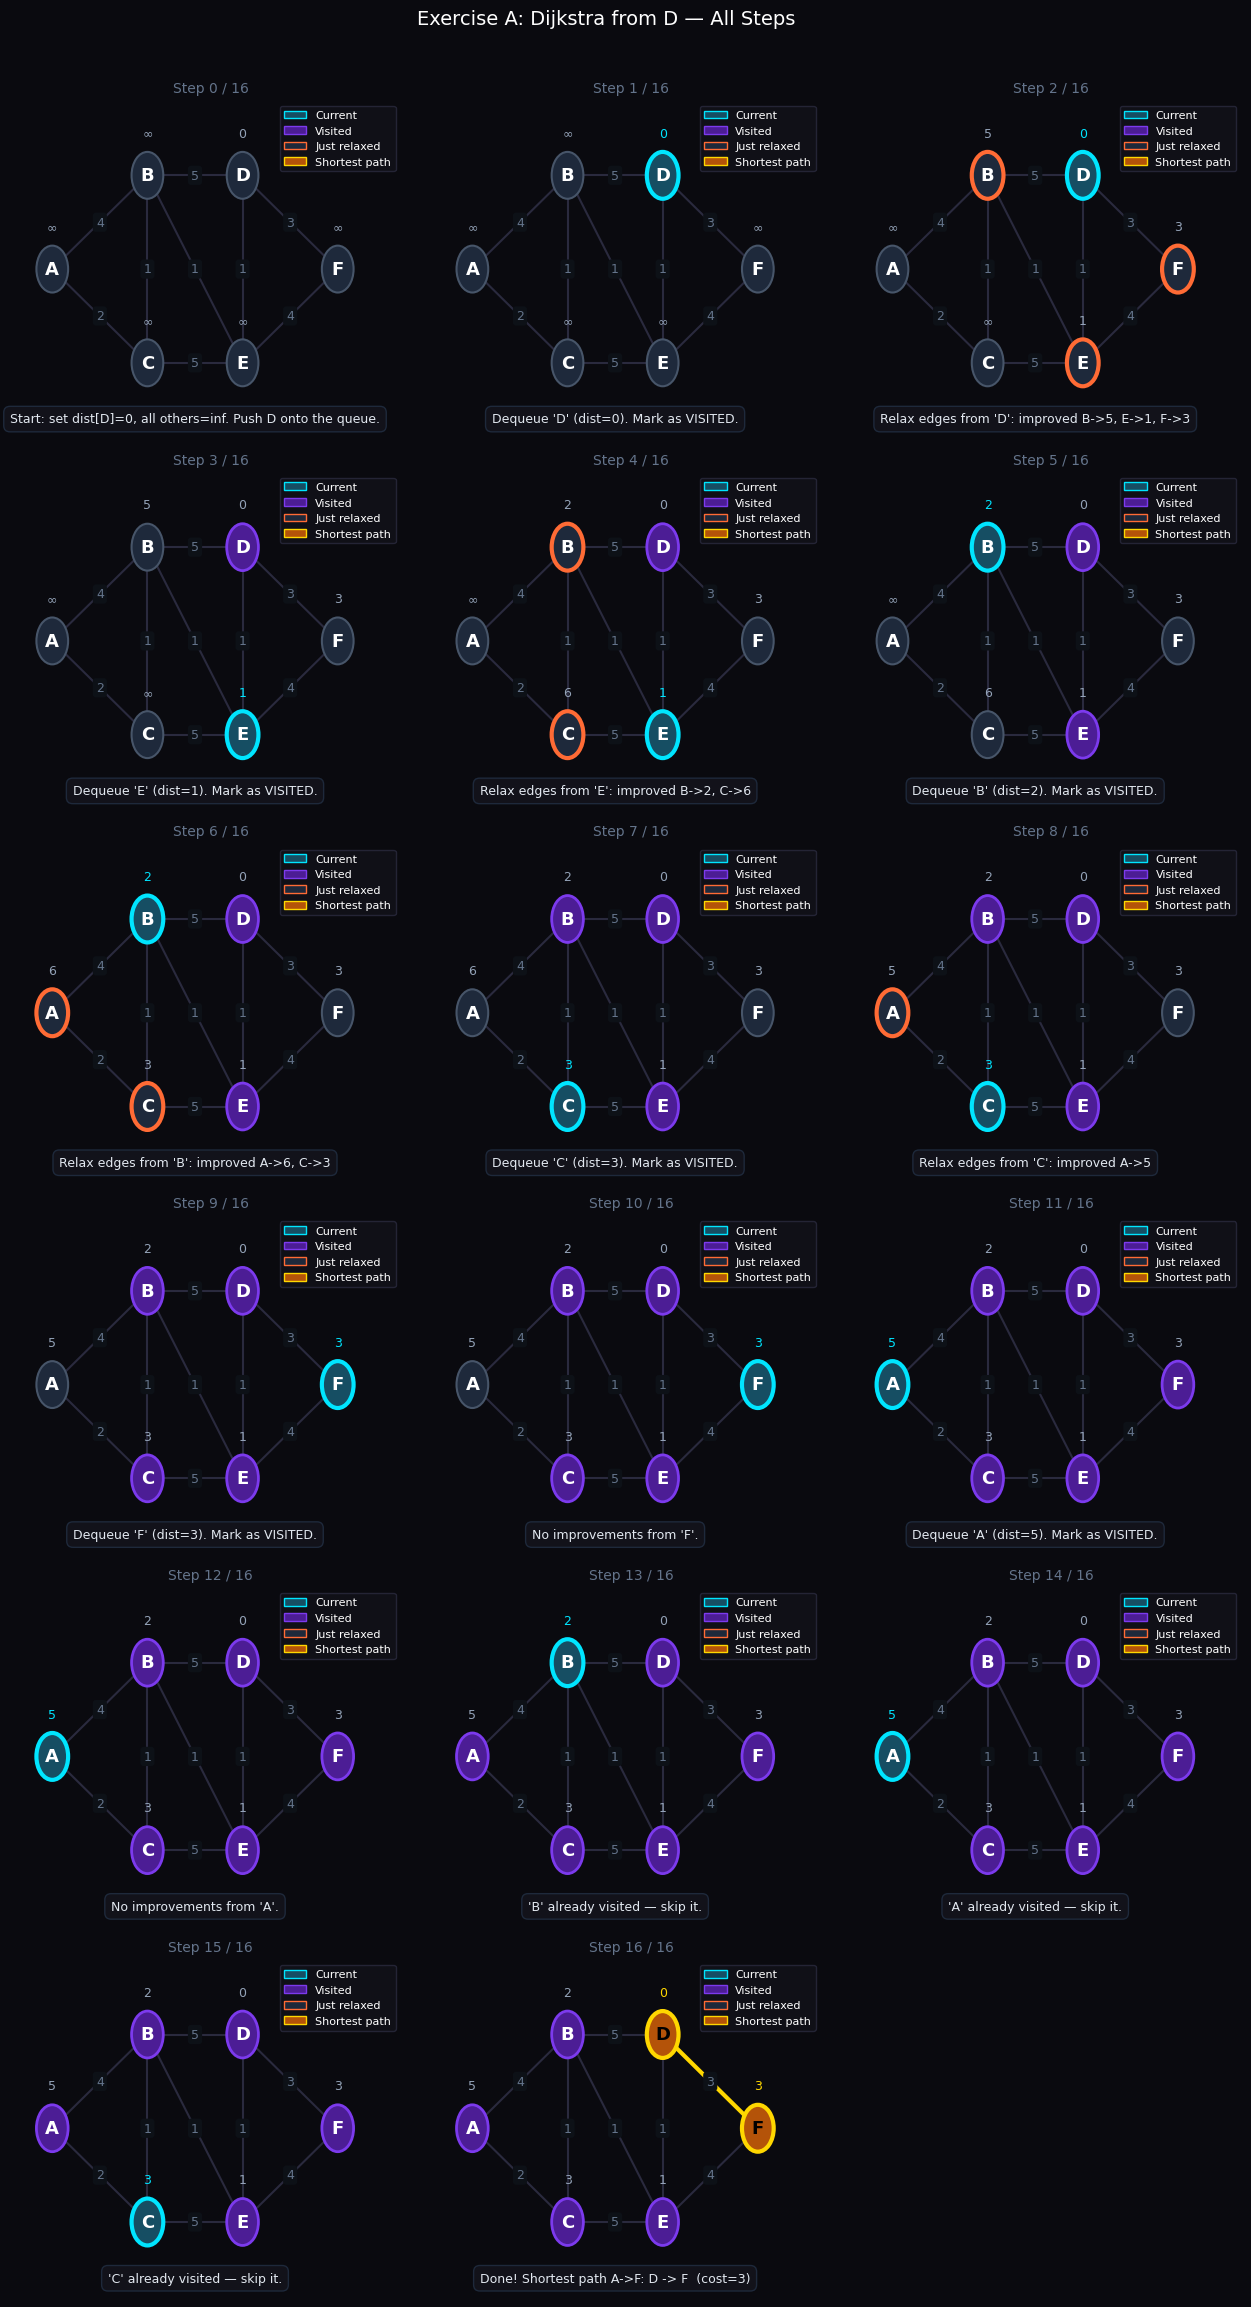

In [21]:
steps_d, dist_d, prev_d = dijkstra_steps(graph, source='D')
path_d_a = reconstruct_path(prev_d, 'D', 'A')
print(f"D -> A: cost={dist_d['A']}, path={' -> '.join(path_d_a)}")

n_d  = len(steps_d)
cols = 3
rows = math.ceil(n_d / cols)

fig, axes = plt.subplots(rows, cols, figsize=(13, rows * 3.8))
fig.patch.set_facecolor('#0a0a0f')
axes = axes.flatten()

for i, snap in enumerate(steps_d):
    draw_frame(axes[i], snap, positions, graph, i, n_d)

for j in range(n_d, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Exercise A: Dijkstra from D — All Steps", color='white', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


### B — Add an edge
Add `A ↔ F` with weight `10`. Does the shortest path A→F change?


In [22]:
import copy
graph_b = copy.deepcopy(graph)
graph_b['A'].append(('F', 10))
graph_b['F'].append(('A', 10))

_, dist_b, prev_b = dijkstra_steps(graph_b, 'A')
path_b = reconstruct_path(prev_b, 'A', 'F')
print(f"Original path: {' → '.join(reconstruct_path(prev, 'A', 'F'))}  cost={dist['F']}")
print(f"New path:      {' → '.join(path_b)}  cost={dist_b['F']}")
print("Path changed?", path_b != reconstruct_path(prev, 'A', 'F'))


Original path: A → C → B → E → F  cost=8
New path:      A → C → B → E → F  cost=8
Path changed? False


### C — Count relaxations
How many edge relaxations does the algorithm perform from source `A`?


In [23]:
relaxations = sum(len(s['updated']) for s in steps if s['current'] is not None and not steps[steps.index(s)-1]['message'].startswith('Done'))
print(f"Total relaxations from A: {relaxations}")


Total relaxations from A: 8
